In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

df = pd.read_csv('ข้อมูลเพาะปลูก.csv')


In [3]:
# ── 1. แปลงวันที่ integer → datetime ──────────────────────────
def parse_thaidate(val):
    try:
        s = str(int(val))
        if len(s) != 8:
            return pd.NaT
        yr = int(s[:4])
        # ถ้า year > 2500 = พ.ศ. → แปลงเป็น ค.ศ.
        if yr > 2500:
            yr -= 543
        return pd.Timestamp(f"{yr}-{s[4:6]}-{s[6:8]}")
    except:
        return pd.NaT

df['plant_date_dt']   = df['plant_date'].apply(parse_thaidate)
df['harvest_date_dt'] = df['produce_da'].apply(parse_thaidate)

# แปลง year_act (พ.ศ. → ค.ศ.)
df['year_ce'] = df['year_act'].apply(lambda y: y - 543 if y > 2500 else y)

In [4]:
# ── 2. คำนวณ growing duration (วัน) ──────────────────────────
df['growing_days'] = (df['harvest_date_dt'] - df['plant_date_dt']).dt.days

# กรอง perennial ที่มีวันที่ผิดปกติ
df['is_annual'] = df['detail_nam'].isin([
    'ข้าวเจ้า','ข้าวเหนียว',
    'ข้าวโพดเลี้ยงสัตว์','มันสำปะหลังโรงงาน'
])

print("Annual crops growing duration (days):")
print(df[df['is_annual']]['growing_days'].describe())

Annual crops growing duration (days):
count    6455.000000
mean      145.510922
std        33.001462
min        90.000000
25%       126.000000
50%       143.000000
75%       158.000000
max       480.000000
Name: growing_days, dtype: float64


In [5]:
# ── 3. Reclassify crop classes ──────────────────────────────
# ปัญหา: tobacco = 2 แปลง, rubber = 30 แปลง
# แนวทาง: ปรับ class scheme ให้สมจริง

class_map = {
    'ข้าวเจ้า':              'rice',
    'ข้าวเหนียว':            'rice',
    'ลำไย':                  'longan',
    'ข้าวโพดเลี้ยงสัตว์':    'corn',
    'มันสำปะหลังโรงงาน':     'cassava',    # ← เพิ่มใหม่! มี 122 แปลง
    'ยางพารา':               'rubber',
    'ยาสูบ':                 'etc',         # ← รวมเข้า etc (2 แปลงเท่านั้น)
    'ปาล์มน้ำมัน':           'etc',
    'มะขาม':                 'etc',
    'หอมแบ่ง(ต้นหอม)':       'etc',
    'ยูคาลิปตัส':            'etc',
    'ฝรั่ง':                 'etc',
    'ฟักทอง':                'etc',
    'กระท่อม':               'etc',
    'มะม่วง':                'etc',
    'ส้มโอ':                 'etc',
    'ผักอื่นๆ':              'etc',
    'กระท้อน':               'etc',
    'ถั่วเขียวผิวมัน':       'etc',
}
df['crop_class'] = df['detail_nam'].map(class_map).fillna('etc')

print("\nRevised class distribution:")
print(df.groupby('crop_class')['act_rai_or'].agg(
    count='count',
    area_rai='sum'
).round(2).sort_values('count', ascending=False))


Revised class distribution:
            count  area_rai
crop_class                 
rice         5720  16329.38
longan        731   2215.06
corn          613   2430.06
cassava       122    623.34
etc            57    182.32
rubber         30    174.96


In [6]:
# ── 4. แปลงเป็น GeoDataFrame ─────────────────────────────────
df_clean = df.dropna(subset=['lat','lng'])
geometry = [Point(lng, lat) for lat, lng
            in zip(df_clean['lat'], df_clean['lng'])]
gdf = gpd.GeoDataFrame(df_clean, geometry=geometry, crs='EPSG:4326')
gdf = gdf.to_crs('EPSG:32647')  # UTM Zone 47N

print(f"\nGeoDataFrame ready: {len(gdf)} parcels")
print(f"CRS: {gdf.crs}")


GeoDataFrame ready: 7269 parcels
CRS: EPSG:32647


In [8]:
# แก้ไข: กรองพิกัดที่ไม่ valid ออกก่อน
# ต.แม่นาเรือ อยู่ใน lat 18.9–19.3, lng 99.5–100.1
valid_mask = (
    df_clean['lat'].between(18.9, 19.3) &
    df_clean['lng'].between(99.5, 100.1)
)
gdf = gdf[valid_mask].copy()
print(f"แถวที่ valid หลังกรองพิกัด: {len(gdf)} (ลบออก {(~valid_mask).sum()} แถว)")

แถวที่ valid หลังกรองพิกัด: 7142 (ลบออก 127 แถว)


In [9]:
# ── 5. Export แยกตาม use case ─────────────────────────────────

# 5a. Training points สำหรับ Phase 1 (RF classification)
#     ใช้ปี 2021–2022 เป็น training | ปี 2023 เป็น validation
gdf_train = gdf[gdf['year_ce'].isin([2021, 2022])]
gdf_val   = gdf[gdf['year_ce'] == 2023]
gdf_train.to_file('training_parcels_2021_2022.shp')
gdf_val.to_file('validation_parcels_2023.shp')
print(f"\nTraining: {len(gdf_train)} | Validation: {len(gdf_val)}")

# 5b. Phenology calendar สำหรับ Phase 2 (DTW template)
#     เฉพาะ annual crops ที่มีวันที่น่าเชื่อถือ
pheno = gdf[gdf['is_annual'] & (gdf['growing_days'] > 30) & (gdf['growing_days'] < 365)]
pheno_cal = pheno.groupby(['crop_class','year_ce']).agg(
    mean_plant_doy  = ('plant_date_dt',   lambda x: x.dt.dayofyear.mean()),
    std_plant_doy   = ('plant_date_dt',   lambda x: x.dt.dayofyear.std()),
    mean_harvest_doy= ('harvest_date_dt', lambda x: x.dt.dayofyear.mean()),
    mean_duration   = ('growing_days',    'mean'),
    n_parcels       = ('act',             'count'),
    total_area_rai  = ('act_rai_or',      'sum'),
).round(1).reset_index()
pheno_cal.to_csv('phenology_calendar_by_crop_year.csv', index=False)
print("\nPhenology calendar (DOY = Day of Year):")
print(pheno_cal.to_string())

# 5c. Crop area per zone สำหรับ Phase 3 (demand estimation)
#     ต้องการ zone boundary ก่อน แต่ prepare ข้อมูลพร้อมไว้
area_summary = gdf.groupby(['year_ce','crop_class'])['act_rai_or'].sum()
area_summary_m2 = (area_summary * 1600).round(0)  # 1 ไร่ = 1,600 m²
area_summary_m2.to_csv('crop_area_m2_by_year.csv')
print("\nCrop area (m²) by year:")
print(area_summary_m2.unstack(fill_value=0))

C:\Users\mpdox\AppData\Local\Temp\ipykernel_26184\192282442.py:7: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_train.to_file('training_parcels_2021_2022.shp')
C:\Users\mpdox\AppData\Roaming\Python\Python314\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'plant_date_dt' to 'plant_da_1'
  ogr_write(
C:\Users\mpdox\AppData\Roaming\Python\Python314\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field plant_da_1 created as String field, though DateTime requested.
  ogr_write(
C:\Users\mpdox\AppData\Roaming\Python\Python314\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'harvest_date_dt' to 'harvest_da'
  ogr_write(
C:\Users\mpdox\AppData\Roaming\Python\Python314\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field harvest_da created as String field, though DateTime requested.
  ogr_write(
C:\Users\mpdox\AppData\Roaming\Python\Python314\site-packages\pyog


Training: 3556 | Validation: 2177

Phenology calendar (DOY = Day of Year):
   crop_class  year_ce  mean_plant_doy  std_plant_doy  mean_harvest_doy  mean_duration  n_parcels  total_area_rai
0     cassava     2020           121.7           55.6              57.5          301.8         15            61.6
1     cassava     2021           120.5           63.1             134.4          300.7         42           262.4
2     cassava     2022           123.6           28.3             145.4          274.5         13            58.2
3     cassava     2023           107.2           64.5             129.0          313.8          5            20.2
4        corn     2020           186.5           68.9             254.1          120.9        103           431.1
5        corn     2021           171.6           43.9             269.1          118.3        211           913.3
6        corn     2022           159.1           46.8             270.4          119.3        136           518.8
7        cor

In [35]:
import rasterio
import numpy as np
import geopandas as gpd
from rasterio.sample import sample_gen

# ── 1. เช็กว่า geometry เป็น Point หรือ Polygon ──────────────
gdf_in = gpd.read_file('training_parcels_2021_2022.shp')
gdf_in = gdf_in.to_crs('EPSG:32647')
print("Geometry type:", gdf_in.geometry.geom_type.value_counts().to_dict())

# ── 2. เช็ก nodata value ของ raster ─────────────────────────
with rasterio.open('S2_drySeason_composite_2022.tif') as src:
    print(f"\nS2 nodata value: {src.nodata}")
    print(f"S2 dtype       : {src.dtypes[0]}")
    # อ่าน band 1 และดูการกระจายของค่า
    band1 = src.read(1)
    print(f"S2 band1 - NaN count  : {np.isnan(band1).sum()}")
    print(f"S2 band1 - Zero count : {(band1==0).sum()}")
    print(f"S2 band1 - Valid count: {(band1>0).sum()}")
    total = band1.size
    valid_pct = (band1>0).sum() / total * 100
    print(f"S2 band1 - Valid %    : {valid_pct:.1f}%")

with rasterio.open('S1_fullYear_weekly_2022.tif') as src:
    print(f"\nS1 nodata value: {src.nodata}")
    print(f"S1 dtype       : {src.dtypes[0]}")
    band1 = src.read(1)  # VV week 1
    print(f"S1 VV band - NaN count   : {np.isnan(band1).sum()}")
    print(f"S1 VV band - Zero count  : {(band1==0).sum()}")
    valid_pct_s1 = (~np.isnan(band1) & (band1!=0)).sum() / band1.size * 100
    print(f"S1 VV band - Valid %     : {valid_pct_s1:.1f}%")

# ── 3. ทดสอบ extract ค่าที่จุดตรงกลาง raster ────────────────
with rasterio.open('S2_drySeason_composite_2022.tif') as src:
    cx = (src.bounds.left + src.bounds.right)  / 2
    cy = (src.bounds.bottom + src.bounds.top) / 2
    test_val = list(sample_gen(src, [(cx, cy)]))[0]
    print(f"\nS2 value at raster center {cx:.0f},{cy:.0f}:")
    print(f"  {test_val[:5]}  ← 0 หรือ NaN = masked")

Geometry type: {'Point': 3556}

S2 nodata value: None
S2 dtype       : float32
S2 band1 - NaN count  : 180981
S2 band1 - Zero count : 0
S2 band1 - Valid count: 117525
S2 band1 - Valid %    : 39.4%

S1 nodata value: None
S1 dtype       : float32
S1 VV band - NaN count   : 726378
S1 VV band - Zero count  : 0
S1 VV band - Valid %     : 39.1%

S2 value at raster center 589320,2110370:
  [ 523.  797.  987. 1467. 2250.]  ← 0 หรือ NaN = masked


In [2]:
"""
=============================================================
Phase 1 — Crop Classification v3b (FINAL)
Mae Na Rua Sub-District, Phayao, Northern Thailand
 
Changes from v3a:
  - ใช้ sample_points_inner_custom (erosion แยกตาม crop)
  - longan erosion 40m (จาก 20m) เพื่อลด mixed pixel กับ rice
  - ข้าม rice จาก LDD — ใช้ SHP เท่านั้น
  - เพิ่ม bootstrap CI สำหรับ minority classes
=============================================================
RESTART KERNEL ก่อนรัน
"""
 
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.sample import sample_gen
from shapely.geometry import Point
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.utils import resample as sk_resample
import matplotlib.pyplot as plt
import joblib, json, warnings
warnings.filterwarnings('ignore')
 
class_labels = {'rice':0, 'corn':1, 'cassava':2, 'longan':3, 'etc':4}
 
# ══════════════════════════════════════════════════════════════
# STEP 0A — SHP training points (point geometry, ปี 2021–2022)
# ══════════════════════════════════════════════════════════════
gdf = gpd.read_file('training_parcels_2021_2022.shp').to_crs('EPSG:32647')
gdf['crop_class'] = gdf['crop_class'].replace('rubber', 'etc')
gdf['class_id']   = gdf['crop_class'].map(class_labels)
gdf = gdf.dropna(subset=['class_id'])
gdf['class_id']   = gdf['class_id'].astype(int)
 
with rasterio.open('S2_drySeason_composite_2022.tif') as src:
    rb = src.bounds
 
gdf = gdf[
    gdf.geometry.x.between(rb.left,  rb.right) &
    gdf.geometry.y.between(rb.bottom, rb.top)
].reset_index(drop=True)
 
coords_shp = list(zip(gdf.geometry.x, gdf.geometry.y))
labels_shp = gdf['class_id'].values
 
print(f"SHP points: {len(coords_shp)}")
print(gdf['crop_class'].value_counts())
 
# ══════════════════════════════════════════════════════════════
# STEP 0B — LDD polygon sampling (minority classes เท่านั้น)
# ══════════════════════════════════════════════════════════════
 
def sample_points_inner_custom(polygon, n_pts, erosion_m=20, seed=42):
    """
    Sample จากส่วนใน polygon หลัง erode erosion_m เมตร
    เพื่อหลีกเลี่ยง mixed pixel ที่ขอบแปลง
    """
    inner = polygon.buffer(-erosion_m)
    if inner.is_empty or inner.area < 1:
        inner = polygon.buffer(-10)   # fallback: erode น้อยลง
    if inner.is_empty or inner.area < 1:
        inner = polygon               # fallback: ใช้ทั้งหมด
 
    rng = np.random.default_rng(seed)
    minx, miny, maxx, maxy = inner.bounds
    pts, attempts = [], 0
    while len(pts) < n_pts and attempts < n_pts * 50:
        x = rng.uniform(minx, maxx)
        y = rng.uniform(miny, maxy)
        if inner.contains(Point(x, y)):
            pts.append((x, y))
        attempts += 1
    return pts if pts else [(inner.centroid.x, inner.centroid.y)]
 
# Erosion ต่างกันตาม crop (เมตร)
EROSION_M = {
    'longan':  40,   # เพิ่มจาก 20 → 40 เพราะ adjacent กับ rice สูง
    'corn':    20,
    'cassava': 20,
    'etc':     20,
}
 
# จำนวนจุดต่อ polygon
POINTS_PER_CLASS = {
    'longan':   3,   # ลดลง — polygon longan มี mixed pixel สูง
    'corn':     8,
    'cassava': 15,
    'etc':      5,
}
 
# Map LDD → crop class
ldd_crop_map = {
    'Active paddy field':            'rice',
    'Abandoned paddy field':         'rice',
    'Active paddy field+Corn':       'rice',
    'Active paddy field+Truck crop': 'rice',
    'Corn':                          'corn',
    'Corn+Tobacco':                  'corn',
    'Corn(Shifting cultivation)':    'corn',
    'Corn/Tamarind':                 'corn',
    'Corn/Truck crop':               'corn',
    'Cassava':                       'cassava',
    'Longan':                        'longan',
    'Teak/Longan':                   'longan',
    'Tamarind/Longan':               'longan',
    'Mango/Longan':                  'longan',
    'Para rubber':                   'etc',
    'Truck crop':                    'etc',
    'Mixed orchard':                 'etc',
    'Mixed perennial':               'etc',
    'Tamarind':                      'etc',
    'Banana':                        'etc',
    'Abandoned field crop':          'etc',
    'Abandoned perenial':            'etc',
    'Abandoned orchard':             'etc',
}
 
# โหลด LDD + filter เฉพาะ agricultural
ldd = gpd.read_file('LDD_landuse.shp').to_crs('EPSG:32647')
ldd['crop_class'] = ldd['LU_DES_EN'].map(ldd_crop_map)
ldd_agri = ldd.dropna(subset=['crop_class']).copy()
ldd_agri['class_id'] = ldd_agri['crop_class'].map(class_labels)
ldd_agri = ldd_agri.dropna(subset=['class_id'])
 
# filter ให้อยู่ใน raster extent
ldd_agri['cx'] = ldd_agri.geometry.centroid.x
ldd_agri['cy'] = ldd_agri.geometry.centroid.y
ldd_agri = ldd_agri[
    ldd_agri['cx'].between(rb.left,  rb.right) &
    ldd_agri['cy'].between(rb.bottom, rb.top)
].reset_index(drop=True)
 
# Sample จุดจาก polygon พร้อม erosion แยกตาม crop
np.random.seed(42)
coords_ldd, labels_ldd = [], []
skipped = 0
 
for _, row in ldd_agri.iterrows():
    crop = row['crop_class']
 
    # ข้าม rice ทั้งหมด — SHP มี rice พอแล้ว และ pure กว่า
    if crop == 'rice':
        continue
 
    n_pts    = POINTS_PER_CLASS.get(crop, 3)
    erosion  = EROSION_M.get(crop, 20)
 
    pts = sample_points_inner_custom(        # ← ใช้ฟังก์ชันใหม่
        row.geometry, n_pts, erosion_m=erosion
    )
    if not pts:
        skipped += 1
        continue
 
    coords_ldd.extend(pts)
    labels_ldd.extend([int(row['class_id'])] * len(pts))
 
labels_ldd = np.array(labels_ldd)
print(f"\nLDD polygon points (erosion, no rice): {len(coords_ldd)}")
print(f"Skipped polygons: {skipped}")
for idx, name in {v:k for k,v in class_labels.items()}.items():
    print(f"  {name:10s}: {(labels_ldd==idx).sum()}")
 
# ══════════════════════════════════════════════════════════════
# STEP 0C — รวม SHP + LDD
# ══════════════════════════════════════════════════════════════
all_coords = coords_shp + coords_ldd
all_labels = np.concatenate([labels_shp, labels_ldd])
 
print(f"\nTotal points: {len(all_coords)}")
print("Final class distribution:")
for idx, name in {v:k for k,v in class_labels.items()}.items():
    print(f"  {name:10s}: {(all_labels==idx).sum()}")
 
# ══════════════════════════════════════════════════════════════
# STEP 1 — Extract features
# ══════════════════════════════════════════════════════════════
def extract(tif_path, coords, prefix, band_idx=None):
    with rasterio.open(tif_path) as src:
        arr = np.array(list(sample_gen(src, coords)), dtype=np.float32)
    if band_idx is not None:
        arr = arr[:, band_idx]
    return pd.DataFrame(arr, columns=[f"{prefix}_{i}" for i in range(arr.shape[1])])
 
N_FEAT  = 6
dry_vv  = [w*N_FEAT+0 for w in range(16)]
dry_vh  = [w*N_FEAT+1 for w in range(16)]
wet_vv  = [w*N_FEAT+0 for w in range(16, 36)]
wet_vh  = [w*N_FEAT+1 for w in range(16, 36)]
 
s2      = extract('S2_drySeason_composite_2022.tif', all_coords, 'S2')
s1_dry  = extract('S1_fullYear_weekly_2022.tif', all_coords, 'S1d',
                   band_idx=dry_vv+dry_vh)
s1_wet  = extract('S1_fullYear_weekly_2022.tif', all_coords, 'S1w',
                   band_idx=wet_vv+wet_vh)
 
s2_cols  = s2.columns.tolist()
s1d_cols = s1_dry.columns.tolist()
s1w_cols = s1_wet.columns.tolist()
all_cols = s2_cols + s1d_cols + s1w_cols
 
X_raw   = pd.concat([s2, s1_dry, s1_wet], axis=1)
medians = X_raw.median()
X       = X_raw.fillna(medians).fillna(0)
y       = all_labels
 
print(f"\nX shape: {X.shape} | NaN: {X.isnull().sum().sum()}")

SHP points: 2830
crop_class
rice       2443
longan      176
corn        174
etc          21
cassava      16
Name: count, dtype: int64

LDD polygon points (erosion, no rice): 3517
Skipped polygons: 0
  rice      : 0
  corn      : 1503
  cassava   : 345
  longan    : 638
  etc       : 1031

Total points: 6347
Final class distribution:
  rice      : 2443
  corn      : 1677
  cassava   : 361
  longan    : 814
  etc       : 1052

X shape: (6347, 86) | NaN: 0


In [7]:
# ── 4. Train RF ───────────────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

param_grid = {
    'n_estimators':     [400,600,800],
    'max_depth':        [20, 10, 30],
    'min_samples_leaf': [2,3,4],
    'min_samples_split': [4,2,3],
    'criterion':        ['entropy'],
    'bootstrap':        [ True, False],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        n_jobs=-1, random_state=42
    ),
    param_grid, cv=cv, scoring='f1_macro', verbose=1
)
gs.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'criterion': ['entropy'], 'max_depth': [20, 10, ...], 'min_samples_leaf': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [8]:
# ══════════════════════════════════════════════════════════════
# STEP 3 — Evaluate
# ══════════════════════════════════════════════════════════════
y_pred = gs.best_estimator_.predict(X_test)
oa     = (y_pred == y_test).mean()
names  = list(class_labels.keys())
 
print(f"\n{'='*55}")
print(f"OA: {oa:.4f}")
print(f"  v2 (SAR wet, SHP only)     : 0.9329")
print(f"  v3a (LDD full, erosion 20m): 0.8299")
print(f"  งานเดิม Pinkaeo 2024       : 0.7365")
print(f"Best params: {gs.best_params_}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred,
      target_names=names, zero_division=0))
 


OA: 0.8362
  v2 (SAR wet, SHP only)     : 0.9329
  v3a (LDD full, erosion 20m): 0.8299
  งานเดิม Pinkaeo 2024       : 0.7365
Best params: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 600}
              precision    recall  f1-score   support

        rice       0.94      0.96      0.95       489
        corn       0.76      0.87      0.81       336
     cassava       1.00      0.67      0.80        72
      longan       0.68      0.62      0.65       163
         etc       0.81      0.71      0.75       210

    accuracy                           0.84      1270
   macro avg       0.84      0.77      0.79      1270
weighted avg       0.84      0.84      0.83      1270



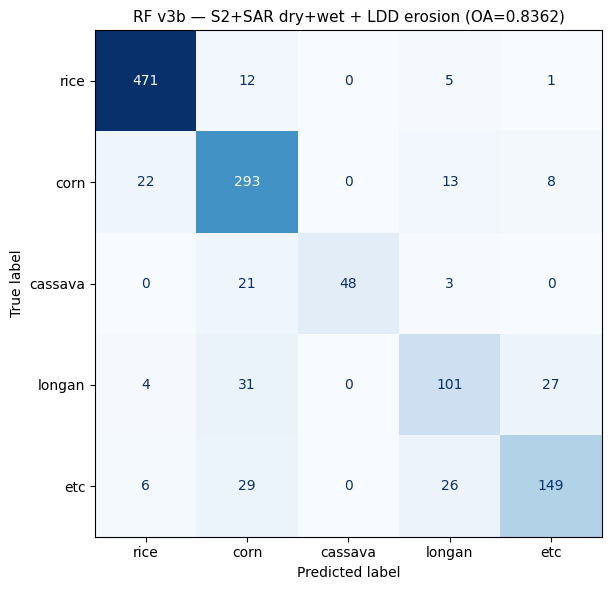

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=names).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'RF v3b — S2+SAR dry+wet + LDD erosion (OA={oa:.4f})', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_v3b_final.png', dpi=300)
plt.show()

In [10]:
# Feature importance
fi = pd.Series(gs.best_estimator_.feature_importances_,
               index=X.columns).sort_values(ascending=False)
s2_imp  = fi[[c for c in fi.index if c.startswith('S2')]].sum()
s1d_imp = fi[[c for c in fi.index if c.startswith('S1d')]].sum()
s1w_imp = fi[[c for c in fi.index if c.startswith('S1w')]].sum()
 
print(f"\nFeature group importance:")
print(f"  S2  dry optical : {s2_imp*100:.1f}%")
print(f"  S1d SAR dry     : {s1d_imp*100:.1f}%")
print(f"  S1w SAR wet     : {s1w_imp*100:.1f}%")
print(f"\nTop 10 features:")
print(fi.head(10).round(4))


Feature group importance:
  S2  dry optical : 44.2%
  S1d SAR dry     : 19.8%
  S1w SAR wet     : 36.0%

Top 10 features:
S2_12     0.0515
S2_11     0.0422
S2_13     0.0412
S2_10     0.0398
S2_2      0.0353
S2_9      0.0346
S1w_33    0.0331
S2_0      0.0316
S1w_37    0.0310
S2_1      0.0293
dtype: float64


In [11]:
# Bootstrap CI
print("\n=== Bootstrap 95% CI (n=1000) ===")
f1_boot = {name:[] for name in names}
for i in range(1000):
    idx = sk_resample(range(len(y_test)), random_state=i)
    yt, yp = y_test[idx], y_pred[idx]
    for name, cid in class_labels.items():
        f1 = f1_score(yt, yp, labels=[cid],
                      average='macro', zero_division=0)
        f1_boot[name].append(f1)
 
for name, vals in f1_boot.items():
    ci  = np.percentile(vals, [2.5, 97.5])
    n   = (y_test == class_labels[name]).sum()
    print(f"  {name:10s}: F1={np.mean(vals):.3f} "
          f"95%CI [{ci[0]:.3f}–{ci[1]:.3f}]  n_test={n}")


=== Bootstrap 95% CI (n=1000) ===
  rice      : F1=0.949 95%CI [0.935–0.962]  n_test=489
  corn      : F1=0.811 95%CI [0.778–0.839]  n_test=336
  cassava   : F1=0.797 95%CI [0.708–0.871]  n_test=72
  longan    : F1=0.648 95%CI [0.586–0.706]  n_test=163
  etc       : F1=0.752 95%CI [0.706–0.800]  n_test=210


In [12]:
# ══════════════════════════════════════════════════════════════
# STEP 4 — Save
# ══════════════════════════════════════════════════════════════
joblib.dump(gs.best_estimator_, 'rf_model_v3b_final.pkl')
joblib.dump(scaler,             'rf_scaler_v3b_final.pkl')
joblib.dump(medians,            'col_medians_v3b_final.pkl')
 
feature_info = {
    's2_cols':  s2_cols,
    's1d_cols': s1d_cols,
    's1w_cols': s1w_cols,
    'all_cols': all_cols,
    'dry_vv':   dry_vv,
    'dry_vh':   dry_vh,
    'wet_vv':   wet_vv,
    'wet_vh':   wet_vh,
    'n_feat':   N_FEAT,
}
with open('feature_info_v3b_final.json','w') as f:
    json.dump(feature_info, f)
with open('class_labels.json','w') as f:
    json.dump(class_labels, f)

In [15]:
"""
Table 1 — Classification Performance Summary (for paper)
Phase 1: RF Crop Classification, Mae Na Rua, Phayao
Final model: v3b only
"""
import pandas as pd
import numpy as np

# ── ข้อมูลจากผลการรัน ─────────────────────────────────────────
results = pd.DataFrame({
    'Class':        ['rice', 'corn', 'cassava', 'longan', 'etc', 'Overall (OA)'],

    # Pinkaeo et al. 2024 (งานเดิม — 6 class, S2 dry season only)
    'Pinkaeo_2024_F1': [0.81, 0.52, 'N/A', 0.72, 'N/A', '0.7365'],

    # v3b: S2 + SAR dry + wet, SHP + LDD erosion sampling
    'v3b_Precision': [0.94, 0.76, 1.00, 0.68, 0.81, '—'],
    'v3b_Recall':    [0.96, 0.87, 0.67, 0.62, 0.71, '—'],
    'v3b_F1':        [0.95, 0.81, 0.80, 0.65, 0.75, '0.8362'],
    'CI_95_low':     [0.935, 0.778, 0.708, 0.586, 0.706, '—'],
    'CI_95_high':    [0.962, 0.839, 0.871, 0.706, 0.800, '—'],
    'n_test':        [489, 336, 72, 163, 210, 1270],
    'vs_Pinkaeo':    ['+0.14', '+0.29', 'new', '−0.07', 'new', '+0.10 OA'],
})

print("="*100)
print("TABLE 1. RF Crop Classification Performance — Model v3b")
print("="*100)
print(results.to_string(index=False))

print("\n\n=== สำหรับใส่ใน paper ===")
print("""
Table 1. Classification accuracy of the RF crop mapping model (v3b).
Features: Sentinel-2 dry-season composite + Sentinel-1 SAR (dry: wk 1–16; wet: wk 17–36).
Training: field survey points (n=2,830) augmented with LDD polygon sampling
          using crop-specific interior erosion (longan: 40 m; others: 20 m).
95% CI estimated by bootstrap resampling (n=1,000).
N/A = class not included in Pinkaeo et al. (2024). OA = Overall Accuracy.

Class     Precision  Recall   F1     95% CI            n_test  vs. Pinkaeo (2024)
rice       0.94      0.96    0.95   [0.935–0.962]      489     +0.14
corn       0.76      0.87    0.81   [0.778–0.839]      336     +0.29
cassava    1.00      0.67    0.80   [0.708–0.871]       72     new class
longan     0.68      0.62    0.65   [0.586–0.706]      163     −0.07
etc        0.81      0.71    0.75   [0.706–0.800]      210     new class
─────────────────────────────────────────────────────────────────────
OA (macro) 0.84      0.77    0.79                     1270     +0.10 OA
                             0.8362 (weighted avg)
""")

print("=== Feature Importance ===")
fi = pd.DataFrame({
    'Feature group':   [
        'S2 dry optical (wk Nov–Apr)',
        'S1 SAR dry season (wk 1–16)',
        'S1 SAR wet season (wk 17–36)',
    ],
    'Importance (%)': [44.2, 19.8, 36.0],
    'Key features':   [
        'S2_12 (SWIR2), S2_11 (SWIR1), S2_13 (NDVI)',
        'VV/VH backscatter Jan–Apr',
        'S1w_33, S1w_37 (VH Aug–Sep = corn grain fill)',
    ],
})
print(fi.to_string(index=False))

print("""
Note: S1 wet season (36.0%) contributed more than S1 dry season (19.8%),
confirming the importance of cloud-agnostic SAR for corn phenology detection
during the monsoon growing period (June–October).
""")

print("=== Key Findings for Discussion ===")
print("""
1. corn F1: 0.52 (Pinkaeo 2024) → 0.81 (v3b)   +0.29
   → SAR wet season (wk 17–36) critical for corn detection
   → Peak features: wk 33–37 (Aug–Sep) = grain fill stage

2. cassava F1 = 0.80 [CI: 0.71–0.87] with n_test=72
   → Reliable estimate via LDD polygon augmentation
   → Previously untested in Pinkaeo 2024

3. longan F1: 0.72 (Pinkaeo 2024) → 0.65 (v3b)  −0.07
   → LDD longan polygons border adjacent rice fields
   → 40 m interior erosion insufficient for small parcels
   → Recommend field validation for longan area estimates

4. OA: 0.7365 → 0.8362  (+10.0 percentage points)
   → Improvement despite harder 5-class problem
   → Attributed to SAR wet season features + augmented training
""")

results.to_csv('table1_v3b_only.csv', index=False)
print("✅ Saved: table1_v3b_only.csv")

TABLE 1. RF Crop Classification Performance — Model v3b
       Class Pinkaeo_2024_F1 v3b_Precision v3b_Recall v3b_F1 CI_95_low CI_95_high  n_test vs_Pinkaeo
        rice            0.81          0.94       0.96   0.95     0.935      0.962     489      +0.14
        corn            0.52          0.76       0.87   0.81     0.778      0.839     336      +0.29
     cassava             N/A           1.0       0.67    0.8     0.708      0.871      72        new
      longan            0.72          0.68       0.62   0.65     0.586      0.706     163      −0.07
         etc             N/A          0.81       0.71   0.75     0.706        0.8     210        new
Overall (OA)          0.7365             —          — 0.8362         —          —    1270   +0.10 OA


=== สำหรับใส่ใน paper ===

Table 1. Classification accuracy of the RF crop mapping model (v3b).
Features: Sentinel-2 dry-season composite + Sentinel-1 SAR (dry: wk 1–16; wet: wk 17–36).
Training: field survey points (n=2,830) augmented

In [16]:
# รันหลัง Grid Search เสร็จและ save model แล้ว
import numpy as np, pandas as pd, geopandas as gpd
import rasterio, joblib, json, warnings
from rasterio.features import rasterize
from rasterio.enums import Resampling
warnings.filterwarnings('ignore')

rf      = joblib.load('rf_model_v3b_final.pkl')
scaler  = joblib.load('rf_scaler_v3b_final.pkl')
medians = joblib.load('col_medians_v3b_final.pkl')
with open('feature_info_v3b_final.json') as f: fi = json.load(f)
with open('class_labels.json') as f: class_labels = json.load(f)

all_cols    = fi['all_cols']
dry_vv,dry_vh = fi['dry_vv'], fi['dry_vh']
wet_vv,wet_vh = fi['wet_vv'], fi['wet_vh']
N_FEAT      = fi['n_feat']
class_names = {v:k for k,v in class_labels.items()}

# LDD mask
ldd = gpd.read_file('LDD_landuse.shp')
agri_l2 = [20,21,22,23,24,25,26,27,29,
           21222,21225,22124,22125,22222,22225,23124]
exclude_en = ['Teak','Fish farm','Cattle farm house',
              'Poultry  farm house','Swine farm house',
              'Bamboo','Rain tree','Bur-flower tree']
agri_ldd = ldd[
    ldd['LU_ID_L2'].isin(agri_l2) &
    ~ldd['LU_DES_EN'].isin(exclude_en)
].copy()

def generate_crop_map_v3b(year):
    with rasterio.open(f'S2_drySeason_composite_{year}.tif') as s:
        s2_data = s.read().astype(np.float32)
        profile = s.profile.copy()
        rows,cols = s.shape
        transform,crs = s.transform, s.crs

    with rasterio.open(f'S1_fullYear_weekly_{year}.tif') as s:
        s1_all = s.read(out_shape=(s.count,rows,cols),
                        resampling=Resampling.bilinear).astype(np.float32)

    s1_dry = s1_all[dry_vv+dry_vh]
    s1_wet = s1_all[wet_vv+wet_vh]

    # LDD mask
    agri_repr = agri_ldd.to_crs(crs)
    agri_mask = rasterize(
        [(g,1) for g in agri_repr.geometry if g and not g.is_empty],
        out_shape=(rows,cols), transform=transform,
        fill=0, dtype=np.uint8)

    stacked  = np.vstack([s2_data, s1_dry, s1_wet])
    X_raster = stacked.reshape(len(all_cols),-1).T
    df = pd.DataFrame(X_raster, columns=all_cols)
    df = df.fillna(medians).fillna(0)

    preds    = rf.predict(scaler.transform(df.values)).astype(np.uint8)
    crop_flat = np.full(rows*cols, 255, dtype=np.uint8)
    crop_flat[agri_mask.flatten().astype(bool)] = \
        preds[agri_mask.flatten().astype(bool)]
    crop_map = crop_flat.reshape(rows, cols)

    profile.update(count=1, dtype='uint8', nodata=255)
    with rasterio.open(f'crop_map_v3b_{year}.tif','w',**profile) as dst:
        dst.write(crop_map, 1)

    pixel_rai = abs(profile['transform'].a * profile['transform'].e)/1600
    ldd_ref   = {'rice':30535,'corn':7894,'longan':3473,'cassava':170,'etc':0}
    print(f"\n=== crop_map_v3b_{year}.tif ===")
    print(f"  {'Class':<12}{'ไร่':>8}  {'LDD ref':>8}  {'ratio':>6}")
    results = {}
    for cid,cname in class_names.items():
        n_px = int((crop_map==cid).sum())
        rai  = round(n_px*pixel_rai)
        ref  = ldd_ref.get(cname,0)
        ratio = f"{rai/ref:.2f}" if ref>0 else "—"
        results[cname] = {'rai':rai,'pixels':n_px,'m2':n_px*pixel_rai*1600}
        print(f"  {cname:<12}{rai:>8,}  {ref:>8,}  {ratio:>6}")
    return results

all_areas = {}
for year in [2020,2021,2022,2023]:
    all_areas[year] = generate_crop_map_v3b(year)
    print(f"✅ crop_map_v3b_{year}.tif saved")

rows_out = [{'year':yr,'crop':cn,'rai':v['rai'],'m2':v['m2']}
            for yr,a in all_areas.items()
            for cn,v in a.items()]
pd.DataFrame(rows_out).to_csv('crop_area_v3b_by_year.csv',index=False)
print("\n✅ crop_area_v3b_by_year.csv saved")


=== crop_map_v3b_2020.tif ===
  Class            ไร่   LDD ref   ratio
  rice          11,230    30,535    0.37
  corn           5,238     7,894    0.66
  cassava            3       170    0.02
  longan         3,972     3,473    1.14
  etc            1,344         0       —
✅ crop_map_v3b_2020.tif saved

=== crop_map_v3b_2021.tif ===
  Class            ไร่   LDD ref   ratio
  rice           9,647    30,535    0.32
  corn           6,302     7,894    0.80
  cassava            2       170    0.01
  longan         4,159     3,473    1.20
  etc            1,678         0       —
✅ crop_map_v3b_2021.tif saved

=== crop_map_v3b_2022.tif ===
  Class            ไร่   LDD ref   ratio
  rice           8,278    30,535    0.27
  corn           7,679     7,894    0.97
  cassava           42       170    0.25
  longan         3,506     3,473    1.01
  etc            2,281         0       —
✅ crop_map_v3b_2022.tif saved

=== crop_map_v3b_2023.tif ===
  Class            ไร่   LDD ref   ratio
  rice 